<a href="https://colab.research.google.com/github/PAJILAPIP/BigData26_B_2411531008_MuhammadFazilAfif/blob/main/Praktikum1/BD_B_P01_2411531008_MuhammadFazilAfif.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import sys, platform, multiprocessing

print("Python :", sys.version.split() [0])
print("OS :", platform.platform())
print("CPU core:", multiprocessing.cpu_count())

for nama in ["pandas", "numpy", "pyarrow", "matplotlib"]:
  try:
    mod =__import__ (nama)
    print(f"{nama:11s}: {mod.__version__}")
  except ImportError:
    print(f" {nama: 11s}: BELUM TERPASANG")

Python : 3.13.15
OS : Linux-6.6.122+-x86_64-with-glibc2.39
CPU core: 2
pandas     : 2.2.3
numpy      : 2.1.3
pyarrow    : 23.0.1
matplotlib : 3.10.0


In [2]:
! free -h
! df -h /content
! java -version

               total        used        free      shared  buff/cache   available
Mem:            12Gi       1.1Gi       9.1Gi       3.7Mi       2.8Gi        11Gi
Swap:             0B          0B          0B
Filesystem      Size  Used Avail Use% Mounted on
overlay         108G   22G   87G  21% /
[0.005s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.005s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
openjdk version "21.0.12" 2026-07-21
OpenJDK Runtime Environment (build 21.0.12+8-1-24.04-Ubuntu)
OpenJDK 64-Bit Server VM (build 21.0.12+8-1-24.04-Ubuntu, mixed mode, sharing)


In [3]:
from google.colab import drive
drive.mount("/content/drive")

import os
DIR_KERJA = "/content/data"
DIR_SIMPAN = "/content/drive/MyDrive/BigData/Praktikum1"
os.makedirs(DIR_KERJA, exist_ok=True)
os.makedirs(DIR_SIMPAN, exist_ok=True)
print(os.listdir(DIR_SIMPAN))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['agregasi_per_jam.csv', 'agregasi_per_jam.parquet', 'pengukuran_kinerja.csv', 'distribusi_per_jam.png']


In [4]:
import time, os, psutil

proses = psutil.Process(os.getpid())
catatan = []# menyimpan hasil pengukuran untuk dibandingkan nanti

catatan = []

def rss_mb():
    return proses.memory_info().rss / 1024 ** 2

def ukur(label, fungsi):
    """Menjalankan fungsi tanpa argumen, mencatat durasi dan pertumbuhan memori."""
    m0, t0 = rss_mb(), time.perf_counter()
    hasil = fungsi()
    detik = time.perf_counter() - t0
    delta = rss_mb() - m0
    catatan.append({"langkah": label, "detik": round(detik, 2),
                    "delta_rss_mb": round(delta, 1)})
    print(f"[{label}] {detik:.2f} s | RSS {delta:+.1f} MB")
    return hasil

In [5]:
import urllib.request

URL = ("https://d37ci6vzurychx.cloudfront.net/trip-data/"
       "yellow_tripdata_2023-01.parquet")

PATH = os.path.join(DIR_KERJA, "yellow_tripdata_2023-01.parquet")

if not os.path.exists(PATH):
    ukur("unduh dataset", lambda: urllib.request.urlretrieve(URL, PATH))

print("Ukuran file:", round(os.path.getsize(PATH) / 1024 ** 2, 1), "MB")

Ukuran file: 45.5 MB


In [6]:
import pyarrow.parquet as pq

meta = pq.ParquetFile(PATH).metadata

print("Jumlah baris :", f"{meta.num_rows:,}")
print("Jumlah kolom :", meta.num_columns)
print("Row group    :", meta.num_row_groups)
print("Nama kolom   :", pq.ParquetFile(PATH).schema.names)

Jumlah baris : 3,066,766
Jumlah kolom : 19
Row group    : 1
Nama kolom   : ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee']


In [7]:
import numpy as np, pandas as pd

def bangkitkan_sintetis(n=5_000_000, seed=42):
    rng = np.random.default_rng(seed)
    awal = pd.Timestamp("2023-01-01")
    pickup = awal + pd.to_timedelta(
        rng.integers(0, 31 * 24 * 60, n), unit="m"
    )
    durasi = rng.integers(1, 90, n)

    return pd.DataFrame({
        "tpep_pickup_datetime": pickup,
        "tpep_dropoff_datetime": pickup + pd.to_timedelta(durasi, unit="m"),
        "passenger_count": rng.integers(1, 5, n).astype("float64"),
        "trip_distance": np.round(rng.gamma(2.0, 1.6, n), 2),
        "payment_type": rng.integers(1, 5, n).astype("int64"),
        "fare_amount": np.round(rng.gamma(4.0, 3.0, n), 2),
        "tip_amount": np.round(rng.gamma(1.5, 1.2, n), 2),
    }).assign(
        total_amount=lambda d: (
            d.fare_amount + d.tip_amount + 3.0
        ).round(2)
    )

if not os.path.exists(PATH):
    bangkitkan_sintetis().to_parquet(PATH, index=False)
    print("Dataset sintetis dibuat di", PATH)

In [8]:
import pandas as pd

KOLOM = ["tpep_pickup_datetime", "tpep_dropoff_datetime",
         "passenger_count", "trip_distance", "payment_type",
         "fare_amount", "tip_amount", "total_amount" ]

penuh = ukur("baca semua kolom", lambda: pd.read_parquet(PATH))
print("Dimensi:", penuh.shape)
print("Memori :", round(penuh.memory_usage(deep=True).sum() / 1024 ** 2, 1), "MB")

del penuh
import gc; gc.collect()

df = ukur("baca kolom terpilih", lambda: pd.read_parquet(PATH, columns=KOLOM))
print("Dimensi:", df.shape)
print("Memori :", round(df.memory_usage(deep=True).sum() / 1024 ** 2, 1), "MB")
df.head()

[baca semua kolom] 2.38 s | RSS +495.1 MB
Dimensi: (3066766, 19)
Memori : 565.6 MB
[baca kolom terpilih] 1.25 s | RSS +207.4 MB
Dimensi: (3066766, 8)
Memori : 187.2 MB


,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,payment_type,fare_amount,tip_amount,total_amount
0,2023-01-01 00:32:10,2023-01-01 00:40:36,1.0,0.97,2,9.3,0.00,14.30
1,2023-01-01 00:55:08,2023-01-01 01:01:27,1.0,1.10,1,7.9,4.00,16.90
2,2023-01-01 00:25:04,2023-01-01 00:37:49,1.0,2.51,1,14.9,15.00,34.90
3,2023-01-01 00:03:48,2023-01-01 00:13:25,0.0,1.90,1,12.1,0.00,20.85
4,2023-01-01 00:10:29,2023-01-01 00:21:19,1.0,1.43,1,11.4,3.28,19.68


In [9]:
df.info(memory_usage="deep")
df.memory_usage(deep=True).sort_values(ascending=False) / 1024 ** 2

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3066766 entries, 0 to 3066765
Data columns (total 8 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   tpep_pickup_datetime   datetime64[us]
 1   tpep_dropoff_datetime  datetime64[us]
 2   passenger_count        float64       
 3   trip_distance          float64       
 4   payment_type           int64         
 5   fare_amount            float64       
 6   tip_amount             float64       
 7   total_amount           float64       
dtypes: datetime64[us](2), float64(5), int64(1)
memory usage: 187.2 MB


,0
tpep_pickup_datetime,23.397568
payment_type,23.397568
tpep_dropoff_datetime,23.397568
passenger_count,23.397568
trip_distance,23.397568
tip_amount,23.397568
fare_amount,23.397568
total_amount,23.397568
Index,0.000126


In [10]:
sebelum = df.memory_usage(deep=True).sum() / 1024 ** 2

df["passenger_count"] = pd.to_numeric(df["passenger_count"], downcast="float")
df["payment_type"] = df["payment_type"].astype("int8").astype("category")

for kol in ["trip_distance", "fare_amount", "tip_amount", "total_amount"]:
    df[kol] = pd.to_numeric(df[kol], downcast="float")

sesudah = df.memory_usage(deep=True).sum() / 1024 ** 2

print(f"{sebelum:.1f} MB -> {sesudah:.1f} MB " f"(hemat {100 * (1 - sesudah / sebelum):.1f}%)")
df.dtypes

187.2 MB -> 119.9 MB (hemat 35.9%)


,0
tpep_pickup_datetime,datetime64[us]
tpep_dropoff_datetime,datetime64[us]
passenger_count,float32
trip_distance,float64
payment_type,category
fare_amount,float32
tip_amount,float32
total_amount,float32


In [11]:
df["durasi_menit"] = (df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]).dt.total_seconds() / 60

print(df[["trip_distance", "durasi_menit", "total_amount"]].describe())
print("\nNilai kosong per kolom:\n", df.isna().sum())

anomali = {
    "jarak <= 0": (df["trip_distance"] <= 0).sum(),
    "durasi <= 0": (df["durasi_menit"] <= 0).sum(),
    "durasi > 180 menit": (df["durasi_menit"] > 180).sum(),
    "total_amount <= 0": (df["total_amount"] <= 0).sum()
}

for k, v in anomali.items():
    print(f"{k:22s}: {v:,} baris ({100*v/len(df):.2f}%)")

       trip_distance  durasi_menit  total_amount
count   3.066766e+06  3.066766e+06  3.066766e+06
mean    3.847342e+00  1.566900e+01  2.702038e+01
std     2.495838e+02  4.259435e+01  2.212666e+01
min     0.000000e+00 -2.920000e+01 -7.510000e+02
25%     1.060000e+00  7.116667e+00  1.540000e+01
50%     1.800000e+00  1.151667e+01  2.016000e+01
75%     3.330000e+00  1.830000e+01  2.870000e+01
max     2.589281e+05  1.002918e+04  1.169400e+03

Nilai kosong per kolom:
 tpep_pickup_datetime         0
tpep_dropoff_datetime        0
passenger_count          71743
trip_distance                0
payment_type                 0
fare_amount                  0
tip_amount                   0
total_amount                 0
durasi_menit                 0
dtype: int64
jarak <= 0            : 45,862 baris (1.50%)
durasi <= 0           : 1,121 baris (0.04%)
durasi > 180 menit    : 3,048 baris (0.10%)
total_amount <= 0     : 25,772 baris (0.84%)


In [12]:
layak = (
    (df["trip_distance"] > 0) & (df["trip_distance"] < 100) &
    df["durasi_menit"].between(1, 180) &
    (df["total_amount"] > 0)
)

bersih = df.loc[layak].copy()
print(f"{len(df):,} baris -> {len(bersih):,} baris (dibuang {len(df)-len(bersih):,})")

3,066,766 baris -> 2,986,911 baris (dibuang 79,855)


In [13]:
CSV = os.path.join(DIR_KERJA, "trips.csv")
ukur("tulis CSV", lambda: bersih.to_csv(CSV, index=False))

print("Parquet:", round(os.path.getsize(PATH) / 1024 ** 2, 1), "MB")
print("CSV    :", round(os.path.getsize(CSV) / 1024 ** 2, 1), "MB")

[tulis CSV] 23.53 s | RSS +5.5 MB
Parquet: 45.5 MB
CSV    : 226.2 MB


In [14]:
def agregasi_bertahap(path, ukuran_chunk=500_000):
    jumlah_baris = 0
    total_nilai = 0.0
    per_jam = {}

    potongan = pd.read_csv(
        path,
        usecols=["tpep_pickup_datetime", "total_amount"],
        parse_dates=["tpep_pickup_datetime"],
        chunksize=ukuran_chunk
    )

    for chunk in potongan:
        jumlah_baris += len(chunk)
        total_nilai += chunk["total_amount"].sum()
        for jam, sub in chunk.groupby(chunk["tpep_pickup_datetime"].dt.hour):
            n, nilai = per_jam.get(jam, (0, 0.0))
            per_jam[jam] = (n + len(sub), nilai + sub["total_amount"].sum())

    return jumlah_baris, total_nilai, per_jam

baris, total, per_jam_chunk = ukur("agregasi chunking", lambda: agregasi_bertahap(CSV))
print(f"{baris:,} baris | rata-rata total_amount {total/baris:.2f}")

[agregasi chunking] 2.62 s | RSS +20.8 MB
2,986,911 baris | rata-rata total_amount 27.33


In [15]:
!pip install -q pyspark==3.5.1
!java -version

[0.000s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.000s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
openjdk version "21.0.12" 2026-07-21
OpenJDK Runtime Environment (build 21.0.12+8-1-24.04-Ubuntu)
OpenJDK 64-Bit Server VM (build 21.0.12+8-1-24.04-Ubuntu, mixed mode, sharing)


In [16]:
from pyspark.sql import SparkSession, functions as F

spark = (SparkSession.builder
    .appName("BD-P01")
    .master("local[*]")              # semua core mesin ini
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate())

spark.sparkContext.setLogLevel("WARN")
print("Spark:", spark.version)

Spark: 3.5.1


In [17]:
sdf = spark.read.parquet(PATH)
sdf.printSchema()
print("Jumlah baris:", ukur("spark count", lambda: sdf.count()))

sdf_bersih = (sdf
    .withColumn(
        "durasi_menit",
        (F.unix_timestamp(F.col("tpep_dropoff_datetime"))
         - F.unix_timestamp(F.col("tpep_pickup_datetime"))) / 60)
    .filter((F.col("trip_distance") > 0) & (F.col("trip_distance") < 100))
    .filter((F.col("durasi_menit") >= 1) & (F.col("durasi_menit") <= 180))
    .filter(F.col("total_amount") > 0))

hasil_spark = (sdf_bersih
    .withColumn("jam", F.hour("tpep_pickup_datetime"))
    .groupBy("jam")
    .agg(F.count("*").alias("jumlah"),
         F.round(F.avg("trip_distance"), 2).alias("rata_jarak"),
         F.round(F.avg("total_amount"), 2).alias("rata_tarif"))
    .orderBy("jam"))

ukur("spark agregasi", lambda: hasil_spark.show(24, truncate=False))

root
 |-- VendorID: long (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: double (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- DOLocationID: long (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- airport_fee: double (nullable = true)

[spark count] 6.19 s | RSS +0.0 MB
Jumlah baris: 3066766
+---+------+----------+----------+
|jam|jumlah|rata_jarak|rata_tarif|
+--

In [18]:
sdf_bersih.createOrReplaceTempView("trips")
spark.sql("""
    SELECT payment_type,
           COUNT(*) AS jumlah,
           ROUND(AVG(total_amount), 2) AS rata_tarif,
           ROUND(AVG(tip_amount), 2) AS rata_tip
    FROM trips
    GROUP BY payment_type
    ORDER BY jumlah DESC
""").show()

hasil_spark.explain()      # rencana eksekusi - perhatikan Exchange / HashAggregate
spark.stop()               # bebaskan sumber daya sebelum lanjut

+------------+-------+----------+--------+
|payment_type| jumlah|rata_tarif|rata_tip|
+------------+-------+----------+--------+
|           1|2385064|      28.1|    4.16|
|           2| 512987|     23.58|     0.0|
|           0|  64106|     29.82|    4.06|
|           4|  15570|     24.11|    0.02|
|           3|   9184|     22.63|     0.0|
+------------+-------+----------+--------+

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Sort [jam#84 ASC NULLS FIRST], true, 0
   +- Exchange rangepartitioning(jam#84 ASC NULLS FIRST, 8), ENSURE_REQUIREMENTS, [plan_id=206]
      +- HashAggregate(keys=[jam#84], functions=[count(1), avg(trip_distance#4), avg(total_amount#16)])
         +- Exchange hashpartitioning(jam#84, 8), ENSURE_REQUIREMENTS, [plan_id=203]
            +- HashAggregate(keys=[jam#84], functions=[partial_count(1), partial_avg(trip_distance#4), partial_avg(total_amount#16)])
               +- Project [trip_distance#4, total_amount#16, hour(tpep_pickup_datetime#1, Some(

In [19]:
bersih["jam"] = bersih["tpep_pickup_datetime"].dt.hour

agregasi = (bersih
    .groupby("jam")
    .agg(jumlah_perjalanan=("total_amount", "size"),
         rata_jarak=("trip_distance", "mean"),
         rata_durasi=("durasi_menit", "mean"),
         rata_tarif=("total_amount", "mean"),
         median_tarif=("total_amount", "median"))
    .round(2)
    .reset_index())



agregasi.to_csv(f"{DIR_SIMPAN}/agregasi_per_jam.csv", index=False)
agregasi.to_parquet(f"{DIR_SIMPAN}/agregasi_per_jam.parquet", index=False)
pd.DataFrame.to_csv(agregasi, f"{DIR_SIMPAN}/pengukuran_kinerja.csv", index=False)

agregasi

,jam,jumlah_perjalanan,rata_jarak,rata_durasi,rata_tarif,median_tarif
0,0,82289,4.04,13.57,28.860001,21.600000
1,1,57766,3.53,12.63,26.450001,21.200001
2,2,40445,3.28,12.07,25.059999,20.520000
3,3,26146,3.58,12.15,26.260000,21.000000
4,4,16618,4.79,13.52,31.719999,22.700001
5,5,16940,6.03,14.70,36.750000,22.040001
6,6,42300,4.80,14.49,30.629999,18.480000
7,7,84569,3.69,14.42,26.889999,18.480000
8,8,114064,3.08,14.33,25.209999,19.100000
9,9,127988,3.09,14.23,25.510000,19.250000


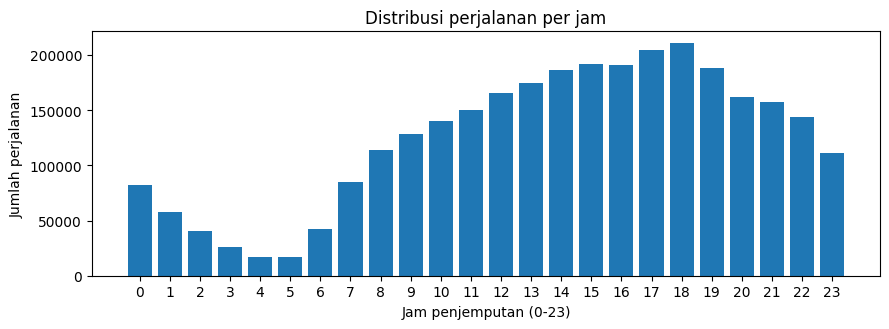

In [20]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.bar(agregasi["jam"], agregasi["jumlah_perjalanan"])
ax.set_xlabel("Jam penjemputan (0-23)")
ax.set_ylabel("Jumlah perjalanan")
ax.set_title("Distribusi perjalanan per jam")
ax.set_xticks(range(0, 24))
fig.tight_layout()
fig.savefig(f"{DIR_SIMPAN}/distribusi_per_jam.png", dpi=150)
plt.show()

# Studi Kasus

Jam tersibuk: 18 (210,858 perjalanan)
Jam tersepi : 4 (16,618 perjalanan)
     hari_kerja  akhir_pekan
jam                         
0         35351        46938
1         17516        40250
2          9452        30993
3          6238        19908
4          6192        10426
5         12462         4478
6         35728         6572
7         74157        10412
8         98431        15633
9        103263        24725
10       105228        35002
11       108784        41755
12       117281        48433
13       123446        50737
14       134562        52179
15       138804        52588
16       136632        54057
17       151736        52663
18       159457        51401
19       139999        48348
20       120931        40858
21       117658        40112
22       104060        39740
23        75215        36120


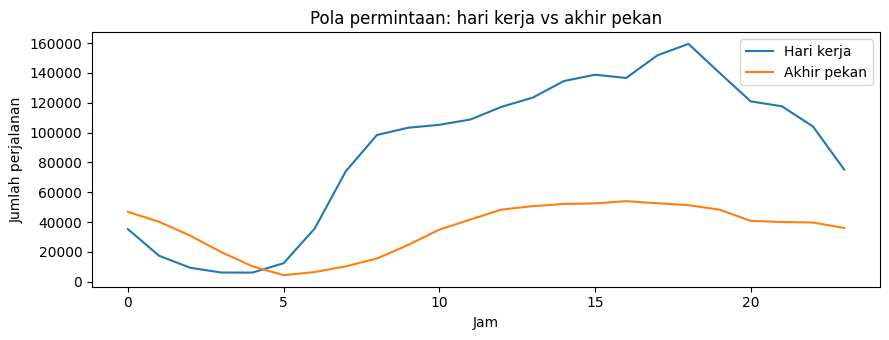

    kelompok  rata_durasi  rata_tarif_per_menit
0  Jam sibuk        15.76                  2.05
1   Jam lain        14.15                  2.14


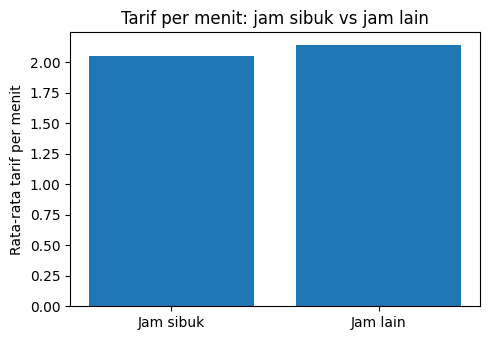

In [21]:
bersih["hari"] = bersih["tpep_pickup_datetime"].dt.day_name()
bersih["akhir_pekan"] = bersih["tpep_pickup_datetime"].dt.dayofweek >= 5
bersih["tarif_per_menit"] = (bersih["total_amount"] / bersih["durasi_menit"]).round(3)

ringkas = (bersih
    .groupby(["akhir_pekan", "jam"])
    .agg(jumlah=("total_amount", "size"),
         rata_durasi=("durasi_menit", "mean"),
         rata_tarif_per_menit=("tarif_per_menit", "mean"))
    .round(2))

ringkas.head(12)

# (1) Jam tersibuk & tersepi (gabungan hari kerja + akhir pekan)
per_jam_total = bersih.groupby("jam")["total_amount"].size()
jam_tersibuk = per_jam_total.idxmax()
jam_tersepi = per_jam_total.idxmin()
print(f"Jam tersibuk: {jam_tersibuk} ({per_jam_total.max():,} perjalanan)")
print(f"Jam tersepi : {jam_tersepi} ({per_jam_total.min():,} perjalanan)")

# (2) Pola hari kerja vs akhir pekan
pola = ringkas.reset_index().pivot(index="jam", columns="akhir_pekan", values="jumlah")
pola.columns = ["hari_kerja", "akhir_pekan"]
print(pola.head(24))

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(pola.index, pola["hari_kerja"], label="Hari kerja")
ax.plot(pola.index, pola["akhir_pekan"], label="Akhir pekan")
ax.set_xlabel("Jam"); ax.set_ylabel("Jumlah perjalanan")
ax.set_title("Pola permintaan: hari kerja vs akhir pekan")
ax.legend(); fig.tight_layout(); plt.show()

# (3) Jam sibuk: durasi lebih pendek, lebih untung per menit?
jam_sibuk = [15, 16, 17, 18]  # sesuaikan dengan hasil (1) Anda
perbandingan = pd.DataFrame({
    "kelompok": ["Jam sibuk", "Jam lain"],
    "rata_durasi": [
        bersih.loc[bersih["jam"].isin(jam_sibuk), "durasi_menit"].mean(),
        bersih.loc[~bersih["jam"].isin(jam_sibuk), "durasi_menit"].mean(),
    ],
    "rata_tarif_per_menit": [
        bersih.loc[bersih["jam"].isin(jam_sibuk), "tarif_per_menit"].mean(),
        bersih.loc[~bersih["jam"].isin(jam_sibuk), "tarif_per_menit"].mean(),
    ],
}).round(2)
print(perbandingan)

fig2, ax2 = plt.subplots(figsize=(5, 3.5))
ax2.bar(perbandingan["kelompok"], perbandingan["rata_tarif_per_menit"])
ax2.set_ylabel("Rata-rata tarif per menit")
ax2.set_title("Tarif per menit: jam sibuk vs jam lain")
fig2.tight_layout(); plt.show()

In [22]:
print(f"1. Alokasikan lebih banyak armada pada jam {jam_tersibuk} karena volume "
      f"perjalanan tertinggi ({per_jam_total.max():,} perjalanan); "
      f"batasan: data hanya satu bulan musim dingin.")
print(f"2. Kurangi jumlah armada aktif pada jam {jam_tersepi} untuk efisiensi "
      f"biaya ({per_jam_total.min():,} perjalanan); "
      f"batasan: pola bisa berbeda saat musim liburan.")
print(f"3. {'Prioritaskan' if perbandingan['rata_tarif_per_menit'][0] > perbandingan['rata_tarif_per_menit'][1] else 'Jangan terlalu berharap pada'} "
      f"jam sibuk untuk profitabilitas per menit ({perbandingan['rata_tarif_per_menit'][0]} vs "
      f"{perbandingan['rata_tarif_per_menit'][1]} per menit); "
      f"batasan: belum memperhitungkan biaya bahan bakar/waktu tunggu pengemudi.")

1. Alokasikan lebih banyak armada pada jam 18 karena volume perjalanan tertinggi (210,858 perjalanan); batasan: data hanya satu bulan musim dingin.
2. Kurangi jumlah armada aktif pada jam 4 untuk efisiensi biaya (16,618 perjalanan); batasan: pola bisa berbeda saat musim liburan.
3. Jangan terlalu berharap pada jam sibuk untuk profitabilitas per menit (2.05 vs 2.14 per menit); batasan: belum memperhitungkan biaya bahan bakar/waktu tunggu pengemudi.


## Latihan

In [23]:
top5 = bersih.nlargest(5, "trip_distance")
top5

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,payment_type,fare_amount,tip_amount,total_amount,durasi_menit,jam,hari,akhir_pekan,tarif_per_menit
1748933,2023-01-19 16:29:36,2023-01-19 18:46:01,1.0,96.70,1,350.000000,50.0,440.750000,136.416667,16,Thursday,False,3.231
526988,2023-01-07 04:29:56,2023-01-07 06:06:16,2.0,93.05,2,542.000000,0.0,564.049988,96.333333,4,Saturday,True,5.855
2402193,2023-01-26 04:55:45,2023-01-26 07:18:50,1.0,92.60,1,262.500000,20.0,312.799988,143.083333,4,Thursday,False,2.186
2902389,2023-01-31 07:04:24,2023-01-31 09:32:54,1.0,92.00,1,334.100006,10.0,368.149994,148.500000,7,Tuesday,False,2.479
927215,2023-01-11 14:23:55,2023-01-11 16:17:58,1.0,90.63,2,250.000000,0.0,272.299988,114.050000,14,Wednesday,False,2.388


In [24]:
for ukuran in [100_000, 1_000_000]:
    hasil = ukur(f"chunking {ukuran}", lambda u=ukuran: agregasi_bertahap(CSV, ukuran_chunk=u))

[chunking 100000] 3.62 s | RSS +69.5 MB
[chunking 1000000] 2.81 s | RSS +93.5 MB


In [25]:
bersih["persen_tip"] = np.where(
    bersih["fare_amount"] == 0, np.nan,
    (bersih["tip_amount"] / bersih["fare_amount"] * 100)
)
rata_tip = bersih.groupby("payment_type")["persen_tip"].mean().round(2)
print(rata_tip)

payment_type
0    20.219999
1    25.910000
2     0.000000
3     0.020000
4     0.150000
Name: persen_tip, dtype: float32


/tmp/ipykernel_52198/3919137761.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rata_tip = bersih.groupby("payment_type")["persen_tip"].mean().round(2)


In [26]:
for komp in ["snappy", "gzip"]:
    path_out = f"{DIR_KERJA}/bersih_{komp}.parquet"
    ukur(f"tulis parquet {komp}", lambda p=path_out, k=komp: bersih.to_parquet(p, compression=k, index=False))
    print(komp, ":", round(os.path.getsize(path_out) / 1024**2, 1), "MB")

[tulis parquet snappy] 1.93 s | RSS -23.6 MB
snappy : 63.3 MB
[tulis parquet gzip] 30.74 s | RSS -12.3 MB
gzip : 51.0 MB


In [33]:
from pyspark.sql import SparkSession, functions as F

spark = (SparkSession.builder
    .appName("BD-P01-Latihan5")
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate())

sdf = spark.read.parquet(PATH)

sdf_bersih = (sdf
    .withColumn(
        "durasi_menit",
        (F.unix_timestamp("tpep_dropoff_datetime") - F.unix_timestamp("tpep_pickup_datetime")) / 60)
    .filter((F.col("trip_distance") > 0) & (F.col("trip_distance") < 100))
    .filter((F.col("durasi_menit") >= 1) & (F.col("durasi_menit") <= 180))
    .filter(F.col("total_amount") > 0))

sdf_bersih.createOrReplaceTempView("trips")

agregasi_spark_sql = spark.sql("""
    SELECT HOUR(tpep_pickup_datetime) AS jam, COUNT(*) AS jumlah_spark
    FROM trips
    GROUP BY jam
    ORDER BY jam
""").toPandas()

banding = agregasi.merge(agregasi_spark_sql, on="jam")
banding["selisih"] = banding["jumlah_perjalanan"] - banding["jumlah_spark"]
print(banding[["jam", "jumlah_perjalanan", "jumlah_spark", "selisih"]])
print("Selisih maksimum:", banding["selisih"].abs().max())

    jam  jumlah_perjalanan  jumlah_spark  selisih
0     0              82289         82289        0
1     1              57766         57766        0
2     2              40445         40445        0
3     3              26146         26146        0
4     4              16618         16618        0
5     5              16940         16940        0
6     6              42300         42300        0
7     7              84569         84569        0
8     8             114064        114064        0
9     9             127988        127988        0
10   10             140230        140230        0
11   11             150539        150539        0
12   12             165714        165714        0
13   13             174183        174183        0
14   14             186741        186741        0
15   15             191392        191392        0
16   16             190689        190689        0
17   17             204399        204399        0
18   18             210858        210858        0
